
# Part B — 09 Forecast Feature Engineering

## Goal

Create a leakage-safe feature table for **Toronto Pearson seasonal snowfall forecasting**.

We now have a long Toronto Pearson snowfall target series. Before modeling, this notebook:

1. applies a stricter winter completeness rule,
2. reconstructs pre-winter Toronto climate predictors from cached ECCC daily files,
3. downloads NOAA/CPC ENSO information,
4. builds only features that would be known before the forecast date,
5. adds lagged snowfall/climatology features,
6. performs a leakage audit,
7. saves one modeling table.

## Forecast setup

**Target**
- July–June seasonal snowfall total, labelled by ending year.

**Forecast issue date**
- approximately **November 1** before the winter.

Therefore we can safely use:
- September–October Toronto temperature,
- September–October Toronto precipitation,
- JAS (Jul–Aug–Sep) Oceanic Niño Index,
- previous winters' snowfall,
- historical rolling snowfall climatology.

We do **not** use any December–April information from the winter being predicted.

---

## Important sample-size constraint

Even with a long snowfall history, ENSO data begin in 1950, so the final supervised dataset will contain only a few dozen winters.

That means:
- keep the feature set compact,
- start with simple baselines,
- use walk-forward validation,
- avoid deep learning.


In [1]:

from pathlib import Path
from io import StringIO
import calendar
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 180)

cwd = Path.cwd()
PROJECT_ROOT = cwd.parent if cwd.name == "notebooks" else cwd

RAW_ECCC_DIR = PROJECT_ROOT / "data" / "raw" / "eccc_pearson"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROJECT_ROOT / "figures"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

TARGET_PATH = PROCESSED_DIR / "pearson_seasonal_snowfall.csv"

if not TARGET_PATH.exists():
    raise FileNotFoundError(
        "pearson_seasonal_snowfall.csv was not found. "
        "Run 08_forecast_data_collection.ipynb first."
    )

print("Project root:", PROJECT_ROOT)
print("Target:", TARGET_PATH)


Project root: /Users/toor/Desktop/Weather-Prediction/toronto-climate-analysis
Target: /Users/toor/Desktop/Weather-Prediction/toronto-climate-analysis/data/processed/pearson_seasonal_snowfall.csv


## 1. Load snowfall target

In [2]:

seasonal = pd.read_csv(TARGET_PATH)

print("Rows:", len(seasonal))
print("Season range:", seasonal["season_year"].min(), "→", seasonal["season_year"].max())

display(seasonal.head())
display(seasonal.tail())


Rows: 91
Season range: 1937 → 2027


,season_year,snowfall_cm,valid_days,missing_days,measurable_snow_days,expected_days,coverage_pct,usable_90pct,full_calendar_window,usable
0,1937,NaN,0,181,0,365,0.000000,False,False,False
1,1938,91.7,242,123,20,365,66.301370,False,True,False
2,1939,207.4,365,0,65,365,100.000000,True,True,True
3,1940,89.5,244,122,31,366,66.666667,False,True,False
4,1941,164.0,365,0,40,365,100.000000,True,True,True


,season_year,snowfall_cm,valid_days,missing_days,measurable_snow_days,expected_days,coverage_pct,usable_90pct,full_calendar_window,usable
86,2023,137.1,363,2,44,365,99.452055,True,True,True
87,2024,67.0,365,1,33,366,99.726776,True,True,True
88,2025,135.6,364,1,42,365,99.726027,True,True,True
89,2026,190.6,365,0,56,365,100.000000,True,True,True
90,2027,0.0,91,93,0,365,24.931507,False,False,False



## 2. Tighten the target quality rule

The original notebook used **90% coverage over the whole July–June season**.

Your diagnostic showed several winters with substantial missing data during the snow-producing months:

- 1993: about 90.6% Oct–Apr coverage
- 1994: about 88.7%
- 2021: about 95.8%

For forecasting, we will use a stricter rule:

> **Whole-season coverage ≥ 90% AND Oct–Apr snowfall coverage ≥ 98%.**

This avoids teaching the model from seasonal totals that may be understated because winter snowfall observations were missing.


### Reconstruct daily snowfall from the processed daily file

In [3]:

DAILY_SNOW_PATH = PROCESSED_DIR / "pearson_daily_snowfall.csv"

if not DAILY_SNOW_PATH.exists():
    raise FileNotFoundError(
        "pearson_daily_snowfall.csv was not found. "
        "Run 08_forecast_data_collection.ipynb first."
    )

snow_daily = pd.read_csv(DAILY_SNOW_PATH, parse_dates=["date"])
snow_daily["year"] = snow_daily["date"].dt.year
snow_daily["month"] = snow_daily["date"].dt.month

if "season_year" not in snow_daily.columns:
    snow_daily["season_year"] = np.where(
        snow_daily["month"] >= 7,
        snow_daily["year"] + 1,
        snow_daily["year"]
    )

winter_daily = snow_daily[
    snow_daily["month"].isin([10, 11, 12, 1, 2, 3, 4])
].copy()

winter_quality = (
    winter_daily.groupby("season_year")
    .agg(
        winter_valid_days=("snowfall_cm", "count"),
        winter_missing_days=("snowfall_cm", lambda s: s.isna().sum())
    )
    .reset_index()
)

def expected_oct_apr_days(season_year):
    start = pd.Timestamp(int(season_year) - 1, 10, 1)
    end = pd.Timestamp(int(season_year), 4, 30)
    return (end - start).days + 1

winter_quality["winter_expected_days"] = (
    winter_quality["season_year"].apply(expected_oct_apr_days)
)

winter_quality["winter_coverage_pct"] = (
    winter_quality["winter_valid_days"]
    / winter_quality["winter_expected_days"]
    * 100
)

display(
    winter_quality.sort_values("winter_coverage_pct").head(15)
)


,season_year,winter_valid_days,winter_missing_days,winter_expected_days,winter_coverage_pct
0,1937,0,120,212,0.000000
90,2027,0,92,212,0.000000
3,1940,121,92,213,56.807512
1,1938,181,31,212,85.377358
57,1994,188,24,212,88.679245
56,1993,192,20,212,90.566038
84,2021,203,9,212,95.754717
77,2014,209,3,212,98.584906
86,2023,210,2,212,99.056604
85,2022,210,2,212,99.056604


In [4]:

target = seasonal.merge(
    winter_quality[
        ["season_year", "winter_valid_days", "winter_missing_days",
         "winter_expected_days", "winter_coverage_pct"]
    ],
    on="season_year",
    how="left"
)

target["usable_strict"] = (
    target["usable"].fillna(False)
    & (target["winter_coverage_pct"] >= 98)
)

print("Original usable seasons:", int(target["usable"].sum()))
print("Strict usable seasons:", int(target["usable_strict"].sum()))

print("\nRemoved by stricter winter-quality rule:")
display(
    target[
        target["usable"].fillna(False)
        & ~target["usable_strict"]
    ][
        ["season_year", "snowfall_cm", "coverage_pct",
         "winter_missing_days", "winter_coverage_pct"]
    ]
)


Original usable seasons: 87
Strict usable seasons: 84

Removed by stricter winter-quality rule:


,season_year,snowfall_cm,coverage_pct,winter_missing_days,winter_coverage_pct
56,1993,91.2,93.424658,20,90.566038
57,1994,115.8,90.136986,24,88.679245
84,2021,122.0,97.534247,9,95.754717



The expected result from your current data is that **1993, 1994, and 2021** are removed by the stricter winter completeness rule.

We keep the original snowfall values unchanged. We are filtering questionable labels, not imputing seasonal snowfall.


## 3. Reconstruct ECCC daily temperature and precipitation


Notebook 08 cached the raw yearly ECCC CSV files locally.

We now read those cached files and extract:

- Mean Temp (°C)
- Total Precip (mm)
- Total Snow (cm)

We use the same Toronto Pearson composite transition:
- legacy station through 2013-06-13,
- current station from 2013-06-14.


In [5]:

LEGACY_STATION_ID = 5097
CURRENT_STATION_ID = 51459

LEGACY_END = pd.Timestamp("2013-06-13")
CURRENT_START = pd.Timestamp("2013-06-14")


def read_cached_station(station_id):
    files = sorted(RAW_ECCC_DIR.glob(f"station_{station_id}_daily_*.csv"))

    if not files:
        raise FileNotFoundError(
            f"No cached files found for ECCC station ID {station_id}. "
            "Run notebook 08 first."
        )

    frames = []

    for path in files:
        df = pd.read_csv(path)
        df["cache_file"] = path.name
        frames.append(df)

    return pd.concat(frames, ignore_index=True)


legacy_raw = read_cached_station(LEGACY_STATION_ID)
current_raw = read_cached_station(CURRENT_STATION_ID)

print("Legacy rows:", len(legacy_raw))
print("Current rows:", len(current_raw))


Legacy rows: 28124
Current rows: 5113


In [6]:

def find_column(columns, candidates):
    normalized = {str(c).strip().lower(): c for c in columns}

    for candidate in candidates:
        key = candidate.strip().lower()
        if key in normalized:
            return normalized[key]

    for c in columns:
        c_lower = str(c).strip().lower()
        for candidate in candidates:
            if candidate.strip().lower() in c_lower:
                return c

    raise KeyError(
        f"Could not find any of {candidates}. "
        f"Available columns: {list(columns)}"
    )


def standardize_eccc_weather(df, source):
    date_col = find_column(
        df.columns,
        ["Date/Time", "Date/Time (LST)", "Date"]
    )

    temp_col = find_column(
        df.columns,
        ["Mean Temp (°C)", "Mean Temp"]
    )

    precip_col = find_column(
        df.columns,
        ["Total Precip (mm)", "Total Precip"]
    )

    snow_col = find_column(
        df.columns,
        ["Total Snow (cm)", "Total Snow"]
    )

    out = pd.DataFrame({
        "date": pd.to_datetime(df[date_col], errors="coerce"),
        "mean_temp_c": pd.to_numeric(df[temp_col], errors="coerce"),
        "total_precip_mm": pd.to_numeric(df[precip_col], errors="coerce"),
        "snowfall_cm": pd.to_numeric(
            df[snow_col].astype(str).str.strip().replace({"T": "0", "t": "0"}),
            errors="coerce"
        ),
        "source": source
    })

    return out.dropna(subset=["date"]).copy()


legacy_weather = standardize_eccc_weather(
    legacy_raw,
    "6158733_legacy"
)

current_weather = standardize_eccc_weather(
    current_raw,
    "6158731_current"
)

legacy_weather = legacy_weather[
    legacy_weather["date"] <= LEGACY_END
]

current_weather = current_weather[
    current_weather["date"] >= CURRENT_START
]

weather = (
    pd.concat([legacy_weather, current_weather], ignore_index=True)
    .sort_values("date")
    .drop_duplicates("date", keep="last")
    .reset_index(drop=True)
)

weather["year"] = weather["date"].dt.year
weather["month"] = weather["date"].dt.month
weather["day"] = weather["date"].dt.day

print("Weather range:", weather["date"].min(), "→", weather["date"].max())
print("Duplicate dates:", weather["date"].duplicated().sum())
display(weather.head())


Weather range: 1937-01-01 00:00:00 → 2026-12-31 00:00:00
Duplicate dates: 0


,date,mean_temp_c,total_precip_mm,snowfall_cm,source,year,month,day
0,1937-01-01,NaN,NaN,NaN,6158733_legacy,1937,1,1
1,1937-01-02,NaN,NaN,NaN,6158733_legacy,1937,1,2
2,1937-01-03,NaN,NaN,NaN,6158733_legacy,1937,1,3
3,1937-01-04,NaN,NaN,NaN,6158733_legacy,1937,1,4
4,1937-01-05,NaN,NaN,NaN,6158733_legacy,1937,1,5


## 4. Build September–October predictors


For a forecast issued around **November 1**, September and October are already observed.

For snow season `2026` (July 2025–June 2026), the pre-winter predictor period is:

- September 2025
- October 2025

So:

`predictor_year = season_year - 1`


In [7]:

prewinter = weather[
    weather["month"].isin([9, 10])
].copy()

prewinter["season_year"] = prewinter["year"] + 1

autumn_features = (
    prewinter.groupby("season_year")
    .agg(
        sep_oct_mean_temp_c=("mean_temp_c", "mean"),
        sep_oct_total_precip_mm=(
            "total_precip_mm",
            lambda s: s.sum(min_count=1)
        ),
        sep_oct_temp_valid_days=("mean_temp_c", "count"),
        sep_oct_precip_valid_days=("total_precip_mm", "count")
    )
    .reset_index()
)

# September + October = 61 days.
autumn_features["sep_oct_temp_coverage_pct"] = (
    autumn_features["sep_oct_temp_valid_days"] / 61 * 100
)

autumn_features["sep_oct_precip_coverage_pct"] = (
    autumn_features["sep_oct_precip_valid_days"] / 61 * 100
)

display(
    autumn_features.sort_values("sep_oct_temp_coverage_pct").head(15)
)


,season_year,sep_oct_mean_temp_c,sep_oct_total_precip_mm,sep_oct_temp_valid_days,sep_oct_precip_valid_days,sep_oct_temp_coverage_pct,sep_oct_precip_coverage_pct
0,1938,NaN,NaN,0,0,0.000000,0.000000
2,1940,NaN,NaN,0,0,0.000000,0.000000
89,2027,18.472414,48.1,29,29,47.540984,47.540984
56,1994,11.663415,91.0,41,41,67.213115,67.213115
76,2014,13.465517,124.6,58,56,95.081967,91.803279
1,1939,11.948333,109.2,60,61,98.360656,100.000000
86,2024,15.566667,51.3,60,61,98.360656,100.000000
85,2023,13.955000,76.0,60,61,98.360656,100.000000
81,2019,13.896667,119.8,60,61,98.360656,100.000000
63,2001,13.478689,87.6,61,61,100.000000,100.000000


In [8]:

FEATURE_COVERAGE_THRESHOLD = 95

autumn_features["autumn_features_usable"] = (
    (autumn_features["sep_oct_temp_coverage_pct"] >= FEATURE_COVERAGE_THRESHOLD)
    & (autumn_features["sep_oct_precip_coverage_pct"] >= FEATURE_COVERAGE_THRESHOLD)
)

print(
    "Usable September–October climate feature years:",
    int(autumn_features["autumn_features_usable"].sum())
)

print("\nYears failing feature completeness:")
display(
    autumn_features[
        ~autumn_features["autumn_features_usable"]
    ][
        ["season_year",
         "sep_oct_temp_coverage_pct",
         "sep_oct_precip_coverage_pct"]
    ].head(30)
)


Usable September–October climate feature years: 85

Years failing feature completeness:


,season_year,sep_oct_temp_coverage_pct,sep_oct_precip_coverage_pct
0,1938,0.000000,0.000000
2,1940,0.000000,0.000000
56,1994,67.213115,67.213115
76,2014,95.081967,91.803279
89,2027,47.540984,47.540984


In [9]:
pip install lxml

Note: you may need to restart the kernel to use updated packages.


## 5. Download NOAA/CPC ENSO data


We use the **Oceanic Niño Index (ONI)** from NOAA's Climate Prediction Center.

For leakage safety, the feature used for each winter is **JAS ONI**:

- July–August–September ONI from the year before the season ends.

Example:

- snow season `2026`
- winter starts in late 2025
- use **JAS 2025 ONI**

The numeric ONI value is the primary feature.

A simple ±0.5°C threshold label is also created for interpretation:
- `>= +0.5` → warm threshold
- `<= -0.5` → cool threshold
- otherwise → neutral threshold

That threshold label is a modeling/descriptive convenience. It should **not** be presented as the full official NOAA episode classification, which also considers persistence across overlapping seasons.

Official source:
https://www.cpc.ncep.noaa.gov/products/analysis_monitoring/enso/oni/v6/index.php


In [10]:
from io import StringIO
import pandas as pd
import requests

ONI_URL = "https://www.cpc.ncep.noaa.gov/data/indices/oni.ascii.txt"


def download_oni_table(url=ONI_URL):
    response = requests.get(url, timeout=30)
    response.raise_for_status()

    # NOAA file format:
    # SEAS  YR   TOTAL   ANOM
    # DJF  1950  25.01  -1.32
    # ...
    oni_long = pd.read_csv(
        StringIO(response.text),
        sep=r"\s+"
    )

    # Keep only July-August-September ONI
    oni = (
        oni_long.loc[
            oni_long["SEAS"].eq("JAS"),
            ["YR", "ANOM"]
        ]
        .rename(
            columns={
                "YR": "Year",
                "ANOM": "JAS"
            }
        )
        .copy()
    )

    oni["Year"] = pd.to_numeric(
        oni["Year"],
        errors="coerce"
    )

    oni["JAS"] = pd.to_numeric(
        oni["JAS"],
        errors="coerce"
    )

    oni = (
        oni.dropna(subset=["Year", "JAS"])
        .sort_values("Year")
        .reset_index(drop=True)
    )

    oni["Year"] = oni["Year"].astype(int)

    return oni


oni = download_oni_table()

print(
    "ONI years:",
    oni["Year"].min(),
    "→",
    oni["Year"].max()
)

print("Rows:", len(oni))

display(oni.head(10))
display(oni.tail(10))

ONI years: 1950 → 2025
Rows: 76


,Year,JAS
0,1950,-0.57
1,1951,0.90
2,1952,-0.20
3,1953,0.68
4,1954,-0.83
5,1955,-0.92
6,1956,-0.52
7,1957,1.03
8,1958,0.32
9,1959,-0.23


,Year,JAS
66,2016,-0.34
67,2017,-0.07
68,2018,0.30
69,2019,0.20
70,2020,-0.43
71,2021,-0.46
72,2022,-0.78
73,2023,1.25
74,2024,-0.04
75,2025,-0.26


In [11]:

oni_features = oni[["Year", "JAS"]].rename(
    columns={
        "Year": "enso_year",
        "JAS": "oni_jas"
    }
)

oni_features["season_year"] = oni_features["enso_year"] + 1

oni_features["oni_phase_threshold"] = np.select(
    [
        oni_features["oni_jas"] >= 0.5,
        oni_features["oni_jas"] <= -0.5
    ],
    [
        "warm_threshold",
        "cool_threshold"
    ],
    default="neutral_threshold"
)

display(oni_features.head(10))


,enso_year,oni_jas,season_year,oni_phase_threshold
0,1950,-0.57,1951,cool_threshold
1,1951,0.90,1952,warm_threshold
2,1952,-0.20,1953,neutral_threshold
3,1953,0.68,1954,warm_threshold
4,1954,-0.83,1955,cool_threshold
5,1955,-0.92,1956,cool_threshold
6,1956,-0.52,1957,cool_threshold
7,1957,1.03,1958,warm_threshold
8,1958,0.32,1959,neutral_threshold
9,1959,-0.23,1960,neutral_threshold


## 6. Add lagged snowfall and climatology features


These features must be calculated using **only earlier winters**.

For winter `t`:

- `snow_lag1_cm` = snowfall from winter `t-1`
- `snow_roll5_mean_cm` = average snowfall of the previous 5 winters
- `snow_roll10_mean_cm` = average snowfall of the previous 10 winters
- `snow_roll10_std_cm` = variability of the previous 10 winters

The `.shift(1)` step is critical. Without it, the current winter's target would leak into its own predictors.


In [12]:
# Start with the full chronological seasonal series
history_all = target.sort_values("season_year").copy()

# Exact previous calendar winter
history_all["snow_lag1_cm"] = (
    history_all["snowfall_cm"]
    .shift(1)
)

# Only use previous calendar seasons in rolling features
history_all["snow_roll5_mean_cm"] = (
    history_all["snowfall_cm"]
    .shift(1)
    .rolling(window=5, min_periods=3)
    .mean()
)

history_all["snow_roll10_mean_cm"] = (
    history_all["snowfall_cm"]
    .shift(1)
    .rolling(window=10, min_periods=5)
    .mean()
)

history_all["snow_roll10_std_cm"] = (
    history_all["snowfall_cm"]
    .shift(1)
    .rolling(window=10, min_periods=5)
    .std()
)

# THEN restrict which seasons may be used as prediction targets
history = history_all[
    history_all["usable_strict"]
].copy()

In [13]:
history_all["previous_season_usable"] = (
    history_all["usable_strict"].shift(1)
)

history_all.loc[
    history_all["previous_season_usable"] != True,
    "snow_lag1_cm"
] = np.nan

## 7. Merge the forecasting feature table

In [14]:

features = (
    history[
        [
            "season_year",
            "snowfall_cm",
            "coverage_pct",
            "winter_coverage_pct",
            "snow_lag1_cm",
            "snow_roll5_mean_cm",
            "snow_roll10_mean_cm",
            "snow_roll10_std_cm"
        ]
    ]
    .merge(
        autumn_features,
        on="season_year",
        how="left"
    )
    .merge(
        oni_features[
            ["season_year", "enso_year", "oni_jas", "oni_phase_threshold"]
        ],
        on="season_year",
        how="left"
    )
    .sort_values("season_year")
    .reset_index(drop=True)
)

# Explicit long-run time index.
features["year_index"] = (
    features["season_year"]
    - features["season_year"].min()
)

display(features.head(15))


,season_year,snowfall_cm,coverage_pct,winter_coverage_pct,snow_lag1_cm,snow_roll5_mean_cm,snow_roll10_mean_cm,snow_roll10_std_cm,sep_oct_mean_temp_c,sep_oct_total_precip_mm,sep_oct_temp_valid_days,sep_oct_precip_valid_days,sep_oct_temp_coverage_pct,sep_oct_precip_coverage_pct,autumn_features_usable,enso_year,oni_jas,oni_phase_threshold,year_index
0,1939,207.4,100.0,100.0,91.7,NaN,NaN,NaN,11.948333,109.2,60,61,98.360656,100.0,True,NaN,NaN,NaN,0
1,1941,164.0,100.0,100.0,89.5,129.533333,NaN,NaN,11.155738,148.1,61,61,100.000000,100.0,True,NaN,NaN,NaN,2
2,1942,96.9,100.0,100.0,164.0,138.150000,NaN,NaN,13.345902,114.3,61,61,100.000000,100.0,True,NaN,NaN,NaN,3
3,1943,182.4,100.0,100.0,96.9,129.900000,129.900000,53.266922,12.255738,156.1,61,61,100.000000,100.0,True,NaN,NaN,NaN,4
4,1944,123.7,100.0,100.0,182.4,148.040000,138.650000,52.242387,11.344262,108.7,61,61,100.000000,100.0,True,NaN,NaN,NaN,5
5,1945,162.3,100.0,100.0,123.7,131.300000,136.514286,48.024141,12.324590,81.4,61,61,100.000000,100.0,True,NaN,NaN,NaN,6
6,1946,89.5,100.0,100.0,162.3,145.860000,139.737500,45.386749,12.081967,186.0,61,61,100.000000,100.0,True,NaN,NaN,NaN,7
7,1947,146.8,100.0,100.0,89.5,130.960000,134.155556,45.638638,13.944262,154.7,61,61,100.000000,100.0,True,NaN,NaN,NaN,8
8,1948,121.9,100.0,100.0,146.8,140.940000,135.420000,43.213907,14.931148,72.1,61,61,100.000000,100.0,True,NaN,NaN,NaN,9
9,1949,126.5,100.0,100.0,121.9,128.840000,138.440000,40.807303,13.047541,213.0,61,61,100.000000,100.0,True,NaN,NaN,NaN,10


## 8. Restrict to rows with defensible predictors

In [15]:

MODEL_FEATURES = [
    "oni_jas",
    "sep_oct_mean_temp_c",
    "sep_oct_total_precip_mm",
    "snow_lag1_cm",
    "snow_roll5_mean_cm",
    "snow_roll10_mean_cm",
    "snow_roll10_std_cm",
    "year_index"
]

model_data = features[
    features["autumn_features_usable"].fillna(False)
].copy()

# ONI starts in 1950, so this naturally removes older winters.
model_data = model_data.dropna(
    subset=["oni_jas", "snowfall_cm"]
).reset_index(drop=True)

print("Rows after strict target quality + predictor availability:", len(model_data))
print(
    "Season range:",
    model_data["season_year"].min(),
    "→",
    model_data["season_year"].max()
)

print("\nMissing values by modeling column:")
display(
    model_data[
        ["snowfall_cm"] + MODEL_FEATURES
    ].isna().sum().to_frame("missing")
)


Rows after strict target quality + predictor availability: 72
Season range: 1951 → 2026

Missing values by modeling column:


,missing
snowfall_cm,0
oni_jas,0
sep_oct_mean_temp_c,0
sep_oct_total_precip_mm,0
snow_lag1_cm,0
snow_roll5_mean_cm,0
snow_roll10_mean_cm,0
snow_roll10_std_cm,0
year_index,0



Some early rows may still have missing rolling-climatology values because there was not enough prior history.

We will retain them in the **full engineered table** for auditability, but create a clean modeling subset requiring all selected features.


In [16]:

model_ready = model_data.dropna(
    subset=MODEL_FEATURES
).reset_index(drop=True)

print("Fully model-ready rows:", len(model_ready))
print(
    "Model-ready range:",
    model_ready["season_year"].min(),
    "→",
    model_ready["season_year"].max()
)

display(
    model_ready[
        ["season_year", "snowfall_cm"] + MODEL_FEATURES
    ].head()
)


Fully model-ready rows: 72
Model-ready range: 1951 → 2026


,season_year,snowfall_cm,oni_jas,sep_oct_mean_temp_c,sep_oct_total_precip_mm,snow_lag1_cm,snow_roll5_mean_cm,snow_roll10_mean_cm,snow_roll10_std_cm,year_index
0,1951,111.8,-0.57,12.640984,100.0,196.4,136.22,141.04,35.388077,12
1,1952,184.8,0.90,12.634426,102.3,111.8,140.68,135.82,35.474836,13
2,1953,53.9,-0.20,11.896721,77.4,184.8,148.28,144.61,35.649231,14
3,1954,124.7,0.68,13.195082,92.5,53.9,134.68,131.76,42.929922,15
4,1955,109.3,-0.83,13.193443,294.6,124.7,134.32,131.86,42.910222,16


## 9. Leakage audit

In [17]:

# Every feature should be available before approximately Nov 1
# of the calendar year season_year - 1.

audit = pd.DataFrame({
    "feature": [
        "oni_jas",
        "sep_oct_mean_temp_c",
        "sep_oct_total_precip_mm",
        "snow_lag1_cm",
        "snow_roll5_mean_cm",
        "snow_roll10_mean_cm",
        "snow_roll10_std_cm",
        "year_index"
    ],
    "latest_information_used": [
        "July–August–September before winter",
        "September–October before winter",
        "September–October before winter",
        "Previous completed snow season",
        "Previous completed snow seasons only",
        "Previous completed snow seasons only",
        "Previous completed snow seasons only",
        "Season identifier only"
    ],
    "available_before_forecast": [
        True, True, True, True, True, True, True, True
    ]
})

display(audit)

assert audit["available_before_forecast"].all()
print("Leakage audit passed for designed features.")


,feature,latest_information_used,available_before_forecast
0,oni_jas,July–August–September before winter,True
1,sep_oct_mean_temp_c,September–October before winter,True
2,sep_oct_total_precip_mm,September–October before winter,True
3,snow_lag1_cm,Previous completed snow season,True
4,snow_roll5_mean_cm,Previous completed snow seasons only,True
5,snow_roll10_mean_cm,Previous completed snow seasons only,True
6,snow_roll10_std_cm,Previous completed snow seasons only,True
7,year_index,Season identifier only,True


Leakage audit passed for designed features.


## 10. Explore relationships — no modeling yet

In [18]:

corr_cols = [
    "snowfall_cm",
    "oni_jas",
    "sep_oct_mean_temp_c",
    "sep_oct_total_precip_mm",
    "snow_lag1_cm",
    "snow_roll5_mean_cm",
    "snow_roll10_mean_cm",
    "snow_roll10_std_cm",
    "year_index"
]

corr = model_ready[corr_cols].corr(numeric_only=True)

display(
    corr["snowfall_cm"]
    .sort_values(ascending=False)
    .to_frame("correlation_with_snowfall")
)


,correlation_with_snowfall
snowfall_cm,1.000000
snow_roll5_mean_cm,0.151454
snow_roll10_mean_cm,0.134665
sep_oct_mean_temp_c,0.105544
snow_lag1_cm,0.032503
snow_roll10_std_cm,-0.087822
sep_oct_total_precip_mm,-0.146721
year_index,-0.154245
oni_jas,-0.262079


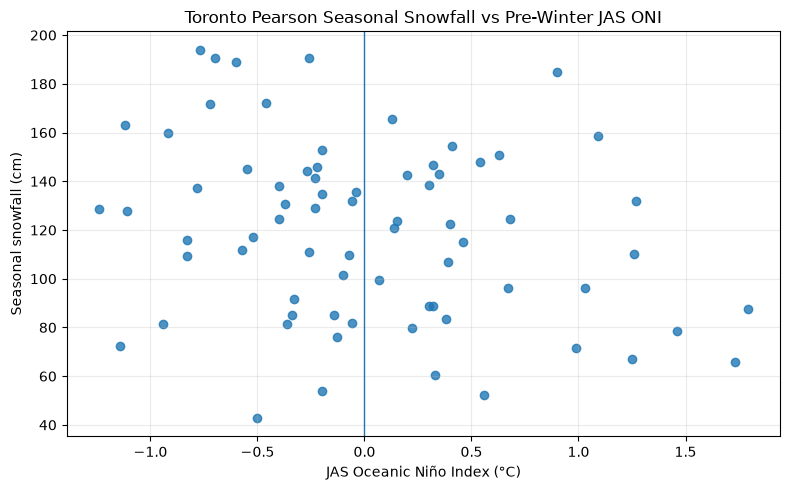

In [19]:

fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(
    model_ready["oni_jas"],
    model_ready["snowfall_cm"],
    alpha=0.8
)

ax.axvline(0, linewidth=1)
ax.set_title("Toronto Pearson Seasonal Snowfall vs Pre-Winter JAS ONI")
ax.set_xlabel("JAS Oceanic Niño Index (°C)")
ax.set_ylabel("Seasonal snowfall (cm)")
ax.grid(alpha=0.25)

fig.tight_layout()
fig.savefig(
    FIGURES_DIR / "part_b_snowfall_vs_oni.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()



### Important interpretation

A weak simple correlation between ONI and Toronto snowfall would **not** mean ENSO is useless.

Toronto snowfall depends on several interacting factors, including:
- temperature,
- storm tracks,
- moisture availability,
- large-scale circulation,
- local weather variability.

The purpose of feature engineering is to give the model plausible pre-winter signals and then test whether they improve **out-of-sample walk-forward forecasts**.


## 11. ENSO phase summary

In [20]:

enso_summary = (
    model_ready.groupby("oni_phase_threshold")
    .agg(
        winters=("snowfall_cm", "count"),
        mean_snowfall_cm=("snowfall_cm", "mean"),
        median_snowfall_cm=("snowfall_cm", "median"),
        std_snowfall_cm=("snowfall_cm", "std")
    )
    .reset_index()
)

display(enso_summary)


,oni_phase_threshold,winters,mean_snowfall_cm,median_snowfall_cm,std_snowfall_cm
0,cool_threshold,17,132.835294,128.8,42.987657
1,neutral_threshold,40,118.210000,123.0,31.608712
2,warm_threshold,15,108.240000,96.1,39.805488



This table is **descriptive only**.

Do not conclude that El Niño or La Niña *causes* a specific Toronto snowfall amount from these group averages. The forecasting question is whether ENSO adds useful predictive information when evaluated prospectively.


## 12. Save engineered features

In [21]:

FEATURES_FULL_PATH = PROCESSED_DIR / "forecast_features_full.csv"
FEATURES_MODEL_PATH = PROCESSED_DIR / "forecast_features_model_ready.csv"

features.to_csv(FEATURES_FULL_PATH, index=False)
model_ready.to_csv(FEATURES_MODEL_PATH, index=False)

print("Saved:")
print(FEATURES_FULL_PATH)
print(FEATURES_MODEL_PATH)

print("\nFinal model-ready shape:", model_ready.shape)


Saved:
/Users/toor/Desktop/Weather-Prediction/toronto-climate-analysis/data/processed/forecast_features_full.csv
/Users/toor/Desktop/Weather-Prediction/toronto-climate-analysis/data/processed/forecast_features_model_ready.csv

Final model-ready shape: (72, 19)


## 13. Final feature dictionary

In [22]:

feature_dictionary = pd.DataFrame([
    ["snowfall_cm", "Target", "Total snowfall for the July–June snow season"],
    ["oni_jas", "ENSO", "NOAA/CPC JAS Oceanic Niño Index before winter"],
    ["sep_oct_mean_temp_c", "Local climate", "Toronto Pearson mean Sep–Oct temperature"],
    ["sep_oct_total_precip_mm", "Local climate", "Toronto Pearson total Sep–Oct precipitation"],
    ["snow_lag1_cm", "History", "Previous usable winter snowfall"],
    ["snow_roll5_mean_cm", "History", "Mean snowfall of preceding winters, 5-season window"],
    ["snow_roll10_mean_cm", "History", "Mean snowfall of preceding winters, 10-season window"],
    ["snow_roll10_std_cm", "History", "Snowfall variability of preceding winters, 10-season window"],
    ["year_index", "Trend", "Long-run chronological index"],
])

feature_dictionary.columns = [
    "column",
    "feature_group",
    "meaning"
]

display(feature_dictionary)


,column,feature_group,meaning
0,snowfall_cm,Target,Total snowfall for the July–June snow season
1,oni_jas,ENSO,NOAA/CPC JAS Oceanic Niño Index before winter
2,sep_oct_mean_temp_c,Local climate,Toronto Pearson mean Sep–Oct temperature
3,sep_oct_total_precip_mm,Local climate,Toronto Pearson total Sep–Oct precipitation
4,snow_lag1_cm,History,Previous usable winter snowfall
5,snow_roll5_mean_cm,History,"Mean snowfall of preceding winters, 5-season w..."
6,snow_roll10_mean_cm,History,"Mean snowfall of preceding winters, 10-season ..."
7,snow_roll10_std_cm,History,"Snowfall variability of preceding winters, 10-..."
8,year_index,Trend,Long-run chronological index



# Next notebook — 10 Forecast Modeling & Walk-Forward Validation

We now have the supervised-learning table.

The next stage should **not** begin with CatBoost.

We will first establish whether ML beats simple forecasting baselines:

1. **Historical climatology**
2. **Rolling 10-year snowfall mean**
3. **Linear Regression / ElasticNet**
4. **CatBoost**

Evaluation will use **expanding-window / walk-forward validation**, not a random train/test split.

Primary regression metrics:
- MAE
- RMSE

Then we will add:
- prediction intervals,
- below / near / above-normal probabilities,
- probabilistic calibration.

Only after we know the forecasting model is useful should we build the retraining + agent automation loop.
